In [2]:
import astropy.coordinates as coord
import astropy.units as u
import numpy as np
import gala.coordinates as gc
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic

import numpy as np
import matplotlib.pyplot as plt 

sim_data_carthesian: [[  -3.599583    -6.811149     5.974194     2.2953708  643.2113
   -84.208405 ]
 [  -4.3761196   -6.9598784    6.100701  -119.00507    339.78268
    27.851671 ]
 [  -3.255104    -6.698136     6.0639486   18.248142   740.82654
   -55.86246  ]
 ...
 [  -4.8829885   -6.4361725    5.9248424 -448.35712   -111.64129
   156.02763  ]
 [  -2.8978992   -7.720932     6.0420012 -185.98178    296.55676
   -22.085653 ]
 [  -3.7653382   -7.2240086    6.0246863 -109.36603    403.08463
   -50.39124  ]]
sim_data_projected: [[ 193.3675608   -26.72736583   10.11368719    4.3706557     2.64241987
  -326.6653709 ]
 [ 188.71462478  -25.0810273     9.97178633   -1.33476812    2.32435694
  -103.04707138]
 [ 195.55143342  -26.59799997   10.25041882    5.86613167    4.08972515
  -358.58698413]
 ...
 [ 187.54384007  -23.21301584    9.31520562  -12.7943228     2.33270113
   180.40632584]
 [ 193.89779126  -29.92259864   11.09768476   -2.61173763    1.05127957
  -145.27660756]
 [ 191.09287607  -

Text(0, 0.5, 'y [kpc]')

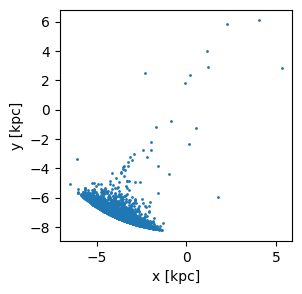

In [6]:
# i = 3
i = 7
data = np.load(f'../project_stream/data/streams/data/simulation_{i}.npz')
sim_data = data['sim_data_carthesian']

for k in data.keys():
    print(f"{k}: {data[k]}")

fig = plt.figure(figsize=(3, 3))
plt.scatter(sim_data[:, 0], sim_data[:, 1], s=1)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')


j = 2 is NGC3201 !


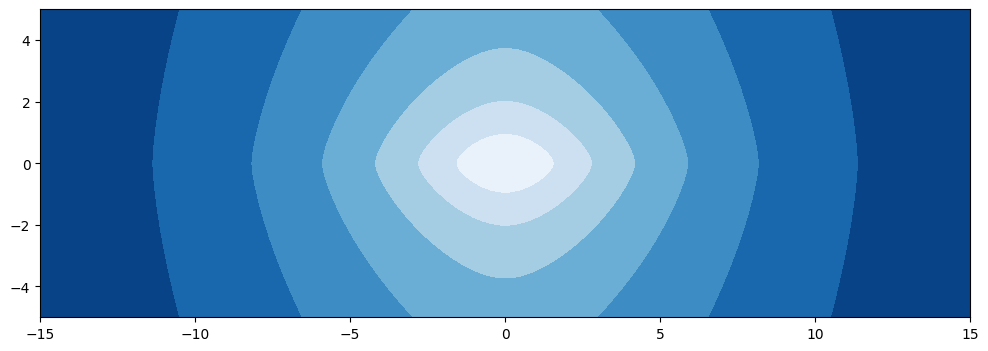

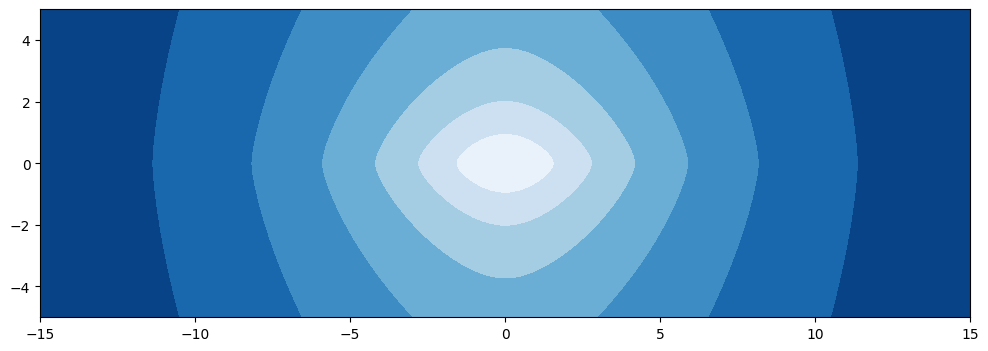

In [7]:
print('j =',data['j'][0], 'is NGC3201 !')

pot = gp.CCompositePotential()

pot['halo'] = gp.NFWPotential(m     = data['m_Triaxial_halo'][0],
                              r_s   = data['r_Triaxial_halo'][0],
                              a     = 1,
                              b     = data['q1_Triaxial_halo'][0],
                              c     = data['q2_Triaxial_halo'][0],
                              units =galactic)

pot['thin_disk'] = gp.MN3ExponentialDiskPotential(m = 4 * np.pi * data['rho_thin_disk'][0]*data['hr_thin_disk'][0]**2 * data['hz_thin_disk'][0],
                                                h_R=data['hr_thin_disk'][0],
                                                h_z=data['hz_thin_disk'][0],
                                                units=galactic,
                                                positive_density=True)
pot['thick_disk'] = gp.MN3ExponentialDiskPotential(m = 4 * np.pi * data['rho_thick_disk'][0] *data['hr_thick_disk'][0]**2 * data['hz_thick_disk'][0],
                                                 h_R=data['hr_thick_disk'][0],
                                                 h_z=data['hz_thick_disk'][0],
                                                 units=galactic,
                                                 positive_density=True)
pot['bulge'] = gp.PowerLawCutoffPotential(m=data['m_bulge'][0],
                                          r_c=data['r_bulge'][0],
                                          alpha=data['alpha_bulge'][0],
                                          units=galactic)

w0 = coord.Galactocentric(x=data['x'][0]*u.kpc, y=data['y'][0]*u.kpc, z=data['z'][0]*u.kpc,
                          v_x=data['vx'][0]*u.km/u.s, v_y=data['vy'][0]*u.km/u.s, v_z=data['vz'][0]*u.km/u.s)
w0 = gd.PhaseSpacePosition(w0)

prog_mass = data['m_progenitor'][0] * u.Msun
b_prog = data['a_progenitor'][0] * u.pc
NGC3201_pot = gp.PlummerPotential(m=prog_mass, b=b_prog, units=galactic)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
x = np.linspace(-15, 15, 100)
z = np.linspace(-5, 5, 100)
pot.plot_contours(grid=(x, 1.0, z), ax=ax)

In [ ]:
from gala.dynamics import mockstream as ms
df = ms.FardalStreamDF()

gen_NGC3201 = ms.MockStreamGenerator(df, pot,
                                  progenitor_potential=NGC3201_pot)
NGC3201_stream, _ = gen_NGC3201.run(w0, prog_mass,
                                    dt=-1*u.Myr, t1=0*u.Gyr, 
                                    t2=-1*u.Gyr, n_particles=3000)

/tmp/ipykernel_1143038/3168678702.py:2: GalaDeprecationWarning: The parameter values of the FardalStreamDF have been updated (fixed) to match the parameter values in the final published version of Fardal+2015. For now, this class uses the Gala modified parameter values that have been adopted over the last several years in Gala. In the future, the default behavior of this class will use the Fardal+2015 parameter values instead, breaking backwards compatibility for mock stream simulations. To use the Fardal+2015 parameters now, set gala_modified=False. To continue to use the Gala modified parameter values, set gala_modified=True.
  df = ms.FardalStreamDF()
        Use name instead. [gala.dynamics.core]


        Use name instead. [gala.dynamics.core]


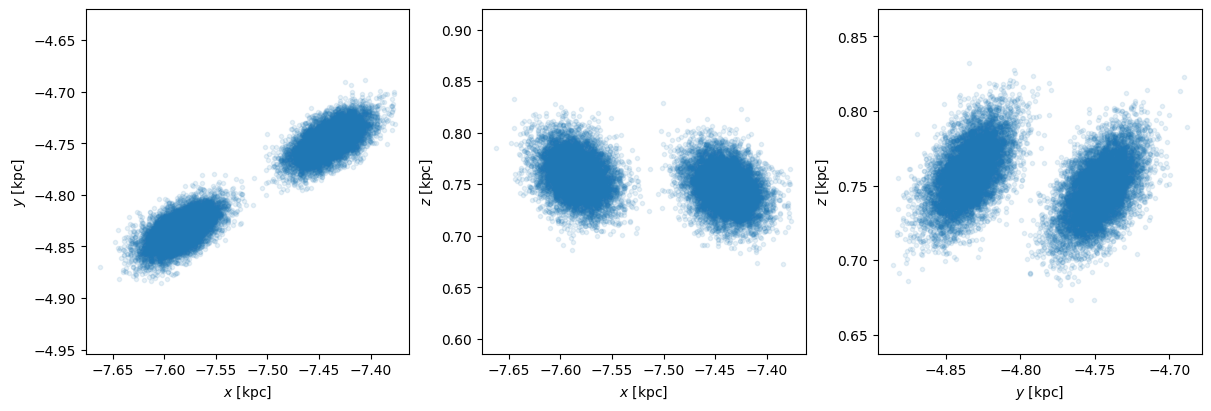

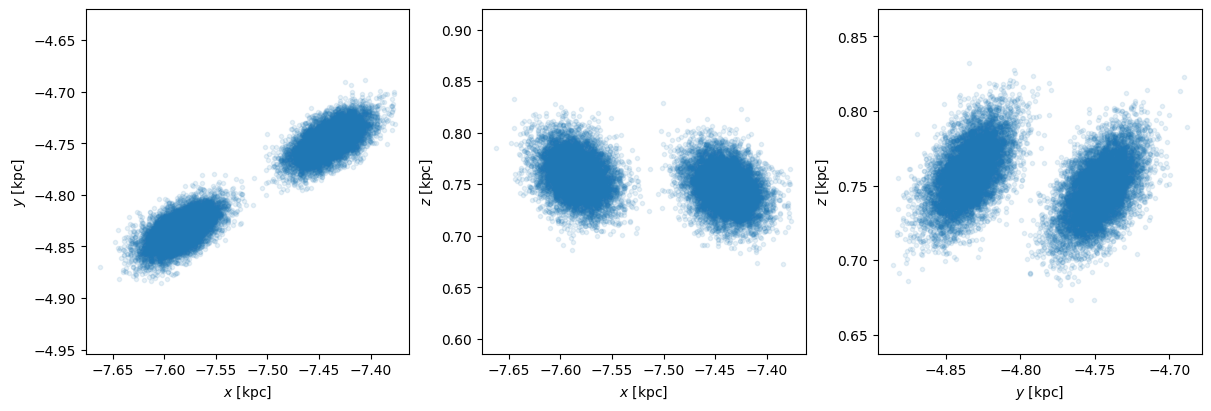

In [11]:
NGC3201_stream.plot(alpha=0.1)


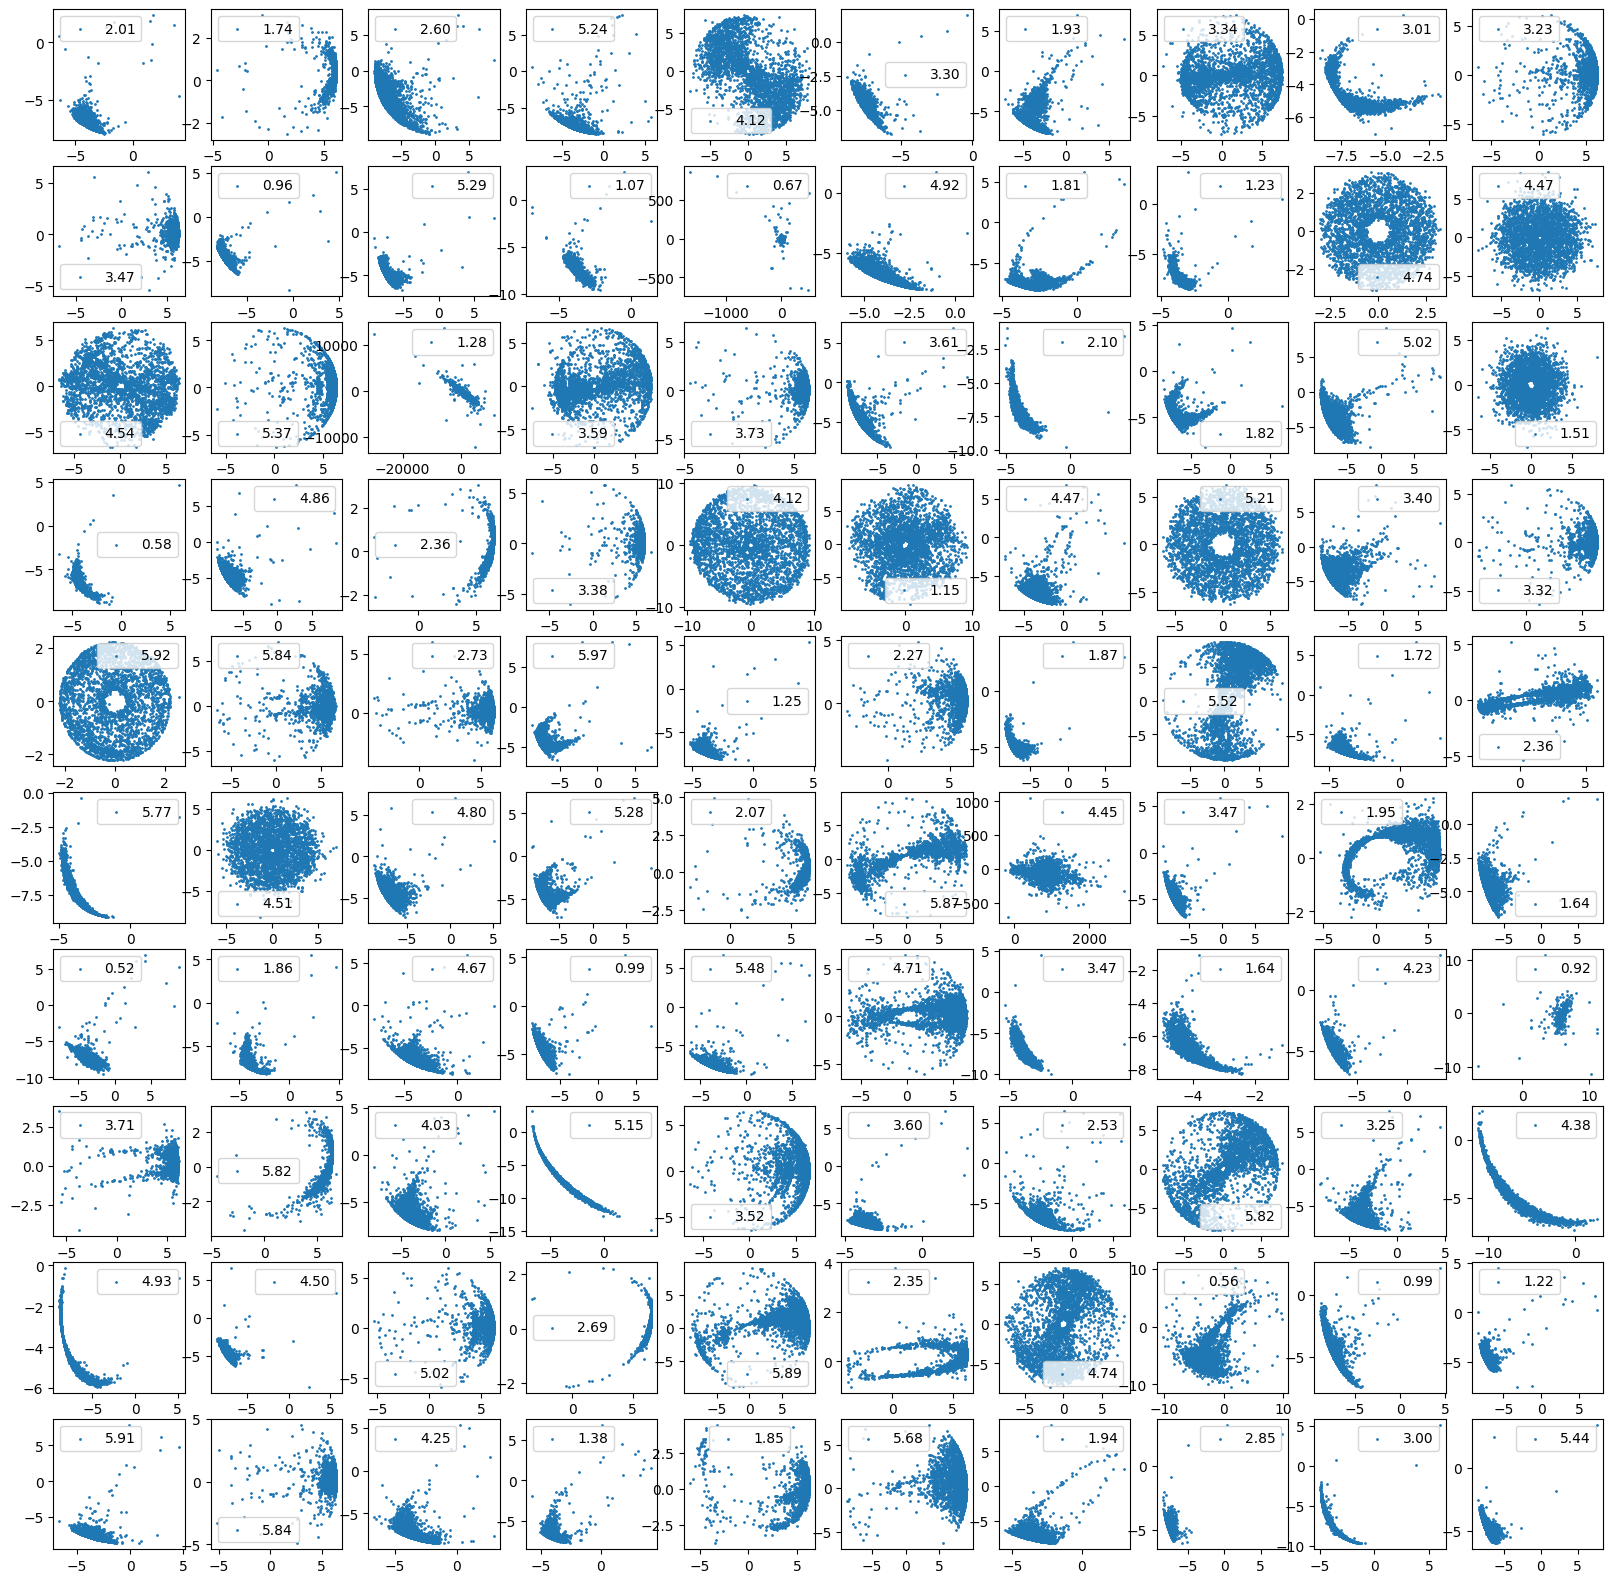

In [17]:
fig = plt.figure(figsize=(20, 20))
for idx, i in enumerate(range(100, 200)):
    data = np.load(f'../project_stream/data/streams/data/simulation_{i}.npz')
    sim_data = data['sim_data_carthesian']

    ax = fig.add_subplot(10, 10, idx+1)
    ax.scatter(sim_data[:, 0], sim_data[:, 1], s=1, label=f"{data['q2_Triaxial_halo'][0]:.2f}")
    ax.legend()